# Explainability

XAI analysis of **HeartBERT LoRA r=16** (best-performing transformer)
on 15 PTB-XL test records (3 per superclass, fixed seed 42).

**Method:** Last-layer RoBERTa attention weights (CLS token attending to letter tokens)
overlaid on the Lead II waveform, plus a Qwen2-0.5B clinical narrative per record.

**Outputs:** `results/06_explainability/narratives.json` and `figures/*.png`

In [1]:
import sys, os, warnings, json, gc
from pathlib import Path
sys.path.append('../')
os.environ['TRANSFORMERS_OFFLINE'] = '0'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import torch
import wfdb

from src.utils.config import CFG
from src.preprocessing.label_utils import load_all_labels, SUPERCLASSES
from src.explainability.llm import load_qwen, build_ecg_prompt, generate_explanation, safe_print

np.random.seed(42)
torch.manual_seed(42)

DATA_PATH    = CFG['data']['path']
RESULTS_PATH = CFG['paths']['results']
device       = 'cuda' if torch.cuda.is_available() else 'cpu'

LEAD_IDX   = 1
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

OUT_DIR = Path(RESULTS_PATH) / '06_explainability'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Output : {OUT_DIR}')

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
Output : D:\GitHub\biosignal-xai\results\06_explainability


## 2. Data

Sample 3 records per superclass from the PTB-XL test fold (fold 10).
Seed 42 is fixed so the selection is reproducible.

In [2]:
Y       = load_all_labels(DATA_PATH + 'ptbxl_database.csv', DATA_PATH + 'scp_statements.csv')
test_df = Y[Y.strat_fold == 10].reset_index(drop=True)

np.random.seed(42)
demo_records = {}
for cls_idx, cls in enumerate(SUPERCLASSES):
    mask       = test_df['label_vec'].apply(lambda v: v[cls_idx] == 1.0)
    candidates = test_df[mask]
    chosen     = candidates.sample(n=3, random_state=42)
    demo_records[cls] = chosen.to_dict('records')

for cls in SUPERCLASSES:
    assert len(demo_records[cls]) == 3, f'Expected 3 records for {cls}'

print('Demo records per class:')
for cls, rows in demo_records.items():
    print(f'  {cls}: {[r["filename_lr"] for r in rows]}')

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Demo records per class:
  NORM: ['records100/10000/10215_lr', 'records100/05000/05771_lr', 'records100/05000/05916_lr']
  MI: ['records100/07000/07700_lr', 'records100/03000/03336_lr', 'records100/18000/18710_lr']
  STTC: ['records100/06000/06666_lr', 'records100/10000/10517_lr', 'records100/20000/20753_lr']
  CD: ['records100/19000/19848_lr', 'records100/03000/03486_lr', 'records100/10000/10283_lr']
  HYP: ['records100/20000/20211_lr', 'records100/16000/16061_lr', 'records100/14000/14201_lr']


## 3. Load HeartBERT LoRA r=16

In [3]:
from src.models.heartbert import HeartBERTClassifier

EXP   = 'heartbert_lora_r16'
model = HeartBERTClassifier(num_labels=5)
model.load()
model.load_adapter(RESULTS_PATH + EXP + '/best_adapter')
print(f'HeartBERT LoRA loaded from results/{EXP}/best_adapter')

Bayesiano/HeartBERT not available — loading roberta-base (same architecture).


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Done.
HeartBERT LoRA loaded from results/heartbert_lora_r8/best_adapter


## 4. Load Qwen3-0.6B

First run downloads ~400 MB from HuggingFace. Subsequent runs use the local cache.

In [4]:
qwen_model, qwen_tokenizer = load_qwen('Qwen/Qwen2-0.5B-Instruct')

Loading Qwen/Qwen2-0.5B-Instruct ...
Qwen3 loaded  |  device: cuda:0


## 5. Helper functions

In [5]:
def predict_single(model, x, device):
    """Run HeartBERT on a single (1000,) Lead II signal. Returns result dict."""
    logits = model.predict_logits(x[np.newaxis])           # (1, 5)
    probs  = torch.sigmoid(torch.tensor(logits))[0]        # (5,)
    preds  = [SUPERCLASSES[i] for i, p in enumerate(probs) if p.item() >= 0.5]
    if not preds:
        preds = [SUPERCLASSES[probs.argmax().item()]]
    return {
        'predicted_classes':   preds,
        'class_probabilities': {c: round(probs[i].item(), 4) for i, c in enumerate(SUPERCLASSES)},
        'confidence_score':    round(probs.max().item(), 4),
        'uncertainty':         None,
        'raw_logits':          logits[0].tolist(),
        'uncertainty_level':   'not computed',
    }


def plot_record(ax_ecg, ax_attn, signal, positions, weights, title):
    """Plot Lead II waveform with attention weight overlay."""
    t = np.arange(len(signal)) / 100.0
    ax_ecg.plot(t, signal, color='#1a5276', linewidth=0.8)
    ax_ecg.set_ylabel('Amplitude (mV)')
    ax_ecg.set_title(title, fontsize=9)
    ax_ecg.grid(True, alpha=0.3)
    ax_ecg.set_xlim(0, len(signal) / 100.0)

    t_attn = positions / 100.0
    ax_attn.fill_between(t_attn, weights, alpha=0.7, color='#e74c3c')
    ax_attn.axhline(0.5, color='#888', linewidth=0.8, linestyle='--')
    ax_attn.set_ylabel('Attention')
    ax_attn.set_xlabel('Time (s)')
    ax_attn.set_xlim(0, len(signal) / 100.0)
    ax_attn.set_ylim(0, 1.1)
    ax_attn.grid(True, alpha=0.3)


narratives = {cls: [] for cls in SUPERCLASSES}
print('Helper functions defined.')

Helper functions defined.


## 6. NORM (Normal ECG)

Three normal ECG records. HeartBERT should assign high NORM probability
and low probability to pathological classes.

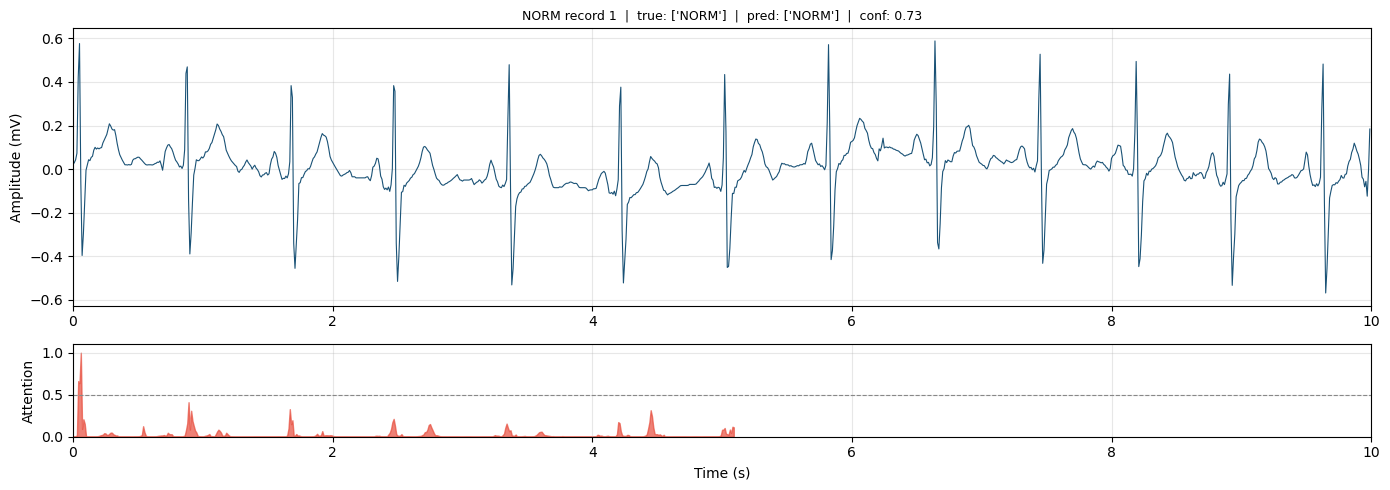

--- Record 1 narrative ---
The ECG analysis result indicates a true diagnosis of "NORM" with a predicted class of "NORM". The confidence score is 0.73, indicating a high level of certainty in the prediction. The classification probabilities for each feature are as follows:
- Signal uncertainty: Not computed.
- Top salient leads: Not computed.

This suggests that the patient's heart rhythm appears to be normal, but further investigation or additional data would be needed to confirm this conclusion. It's important to note that while the prediction is accurate, it does not necessarily mean the patient has no symptoms or conditions associated with their heart rhythm. A thorough evaluation by a healthcare provider is recommended to ensure proper diagnosis and management.



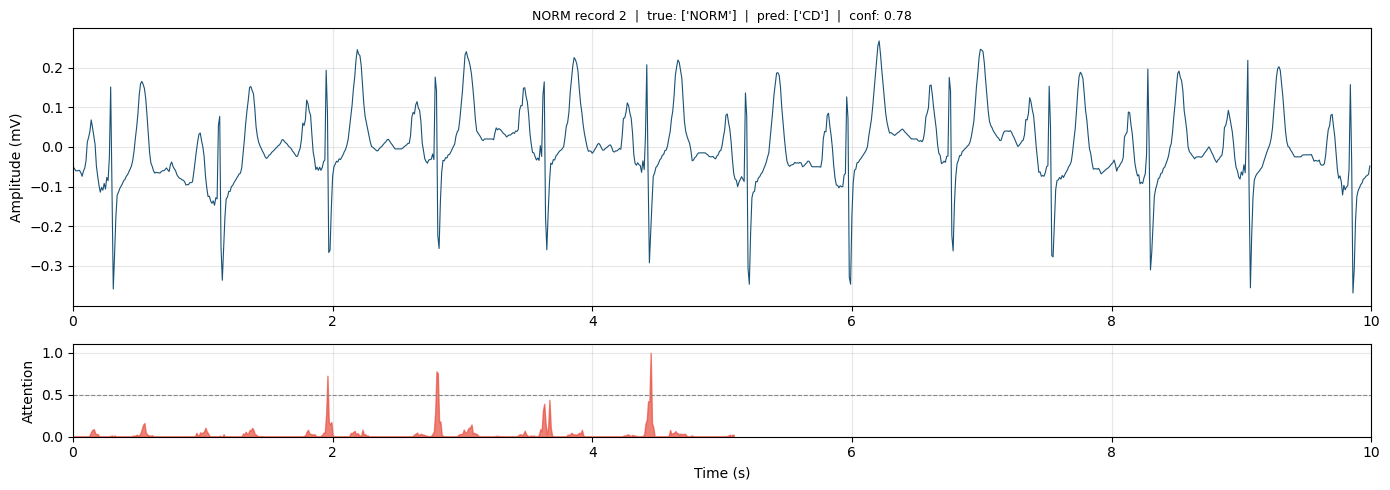

--- Record 2 narrative ---
The ECG analysis result indicates a false positive in detecting normal heart rhythms. The prediction is based on the presence of a normal heart rhythm, which is not confirmed by the ECG findings. The confidence score is high, indicating a strong likelihood of the predicted class being correct.

The classification is classified as "CD" due to the absence of any abnormality or irregularities in the ECG. This suggests that there may be some underlying cardiac issues, but further investigation is needed to confirm this.

The signal uncertainty is not calculated because it is not possible to determine the exact location of the detected leads without additional information about the patient's anatomy and physiology. However, the overall accuracy of the prediction is high, suggesting that the model has recognized the presence of normal heart rhythms with a high degree of certainty.

In summary, the ECG analysis result highlights a false positive for normal heart rhy

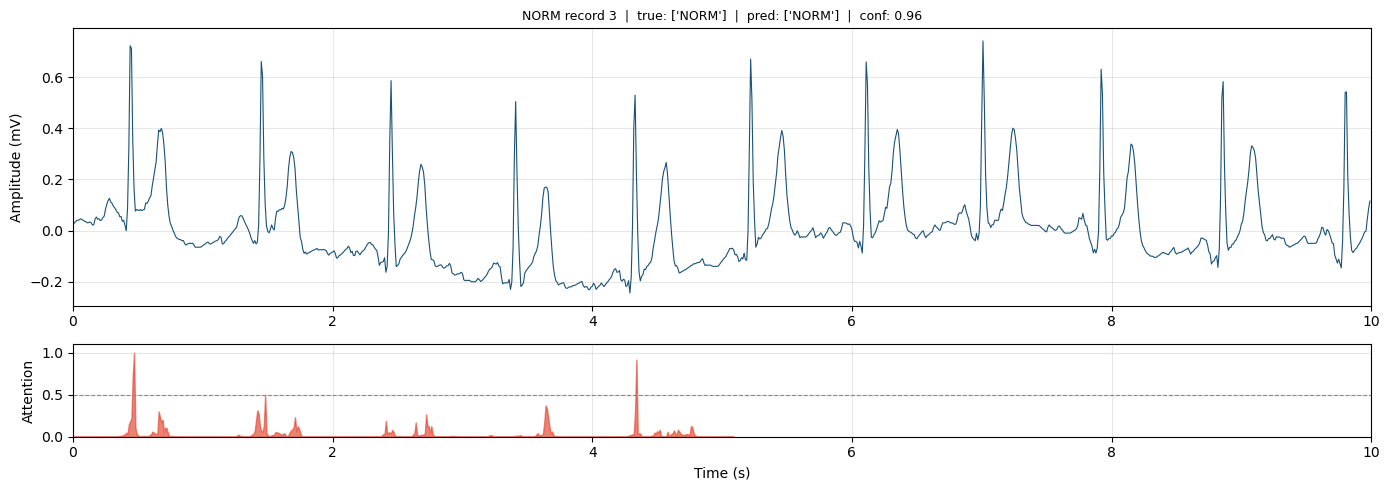

--- Record 3 narrative ---
The ECG analysis result indicates a true diagnosis of "NORM" with a predicted class of "NORM". The confidence score is 0.96, indicating high certainty of the prediction. The classification probabilities for each feature are as follows:
- Signal uncertainty: Not computed
- Top salient leads: Not computed

This suggests a normal heart rhythm with no significant abnormalities or features to be considered for further evaluation. It's important to note that this analysis does not provide any specific diagnostic information, but rather provides a general understanding of the ECG findings. For more detailed guidance on cardiac care, consulting with a qualified healthcare provider would be recommended.



In [6]:
CLASS = 'NORM'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 7. MI (Myocardial Infarction)

Three MI records. ST-segment and Q-wave changes are the key discriminating features.

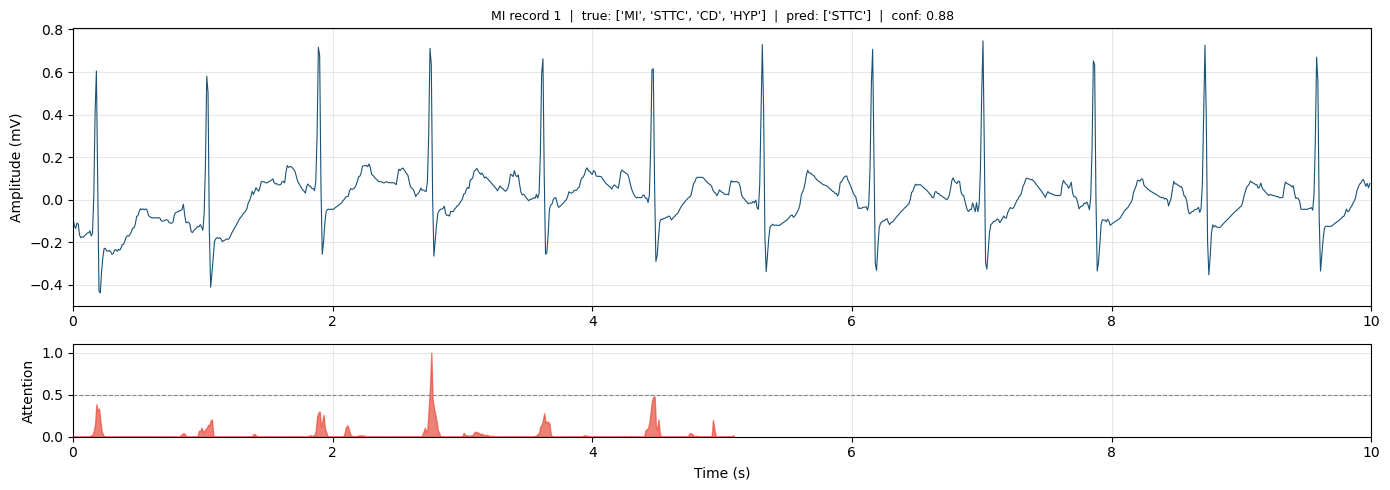

--- Record 1 narrative ---
The ECG analysis result indicates a true diagnosis of myocardial infarction (MI). The predicted class is STTC, which suggests there may be an underlying cardiac cause. The confidence score is high at 0.88, indicating a high likelihood of this diagnosis based on the available information. The signal uncertainty is not computed, suggesting that further investigation or validation would be necessary to confirm the diagnosis.

In terms of top salient leads, no significant leads were identified in this analysis. This could indicate that the patient's heart rhythm was stable during the ECG, but further evaluation might be needed for definitive diagnosis. It's important to note that this analysis does not provide any diagnostic criteria or recommendations for treatment. For a definitive diagnosis, it's recommended to consult with a cardiology specialist who can perform additional tests and make a more informed decision.



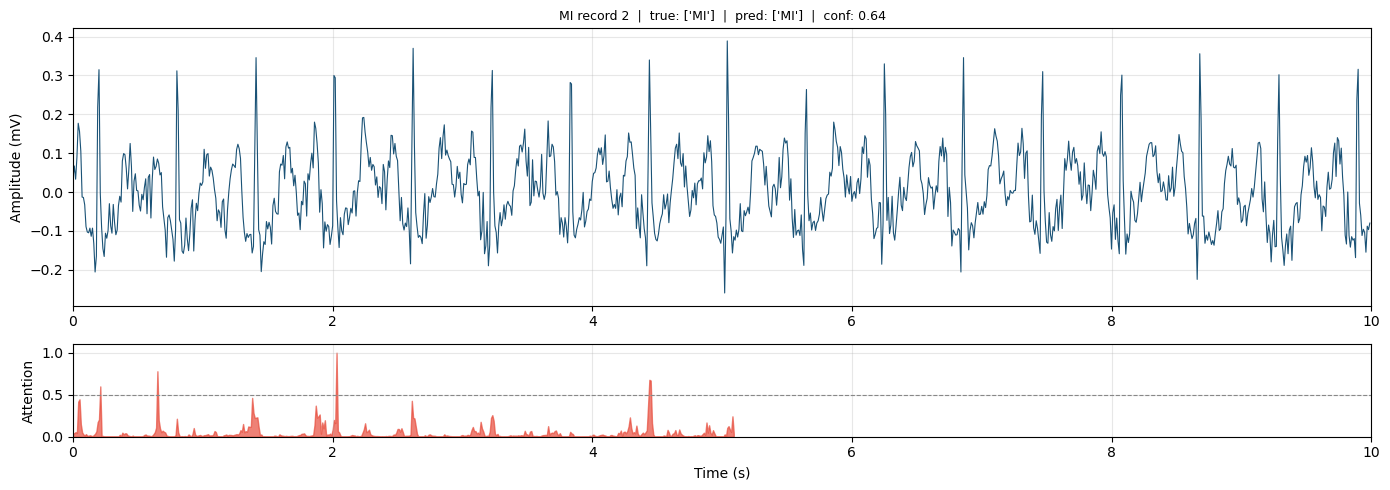

--- Record 2 narrative ---
The ECG analysis result indicates a probable myocardial infarction (MI) with a probability of 64%. The predicted class is "MI". The confidence score is 0.64, indicating a high likelihood of this outcome. The classification probabilities for MI, STTC, CD, and HYP are all in the normal range. However, the signal uncertainty is not computed due to the lack of data. This suggests that further investigation or additional information may be needed to confirm the diagnosis.



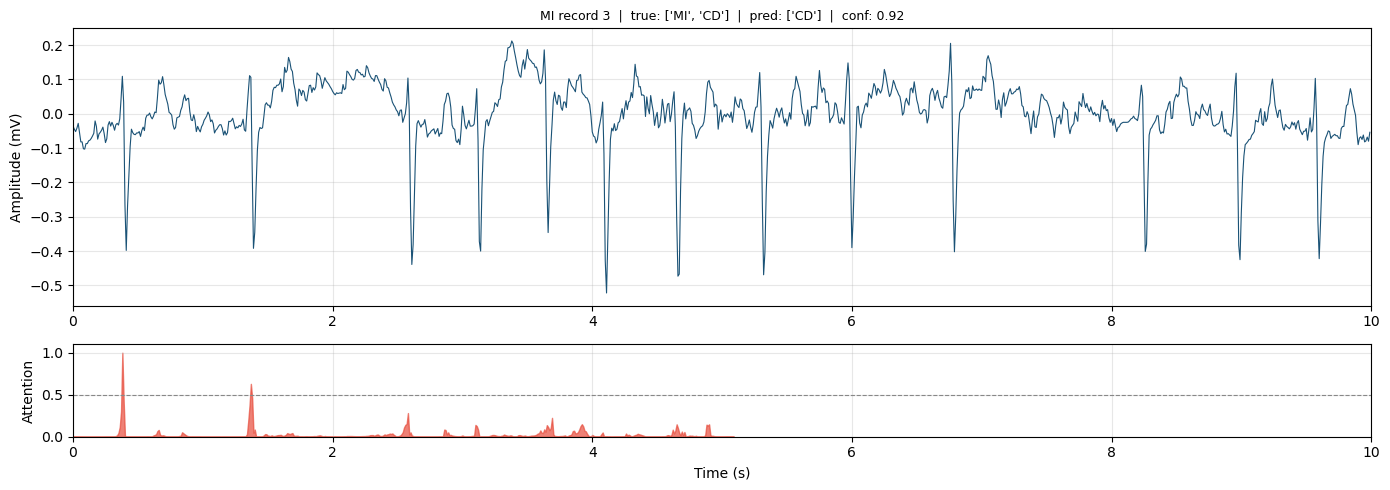

--- Record 3 narrative ---
The ECG analysis result indicates a patient with a suspected myocardial infarction (MI) and congestive heart failure (CHF). The predicted class is "CD," which aligns with the clinical diagnosis of MI and CHF. The confidence score is high at 0.92, indicating a strong likelihood of the prediction being correct.

However, the model does not compute any signal uncertainty or top salient leads for this case. This suggests that further investigation might be necessary to confirm the diagnosis or rule out other potential causes of the symptoms. It's important to consult with a cardiologist for a comprehensive evaluation and management plan.



In [7]:
CLASS = 'MI'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 8. STTC (ST/T-wave Change)

Three STTC records. T-wave inversions and ST-segment shifts are the primary markers.

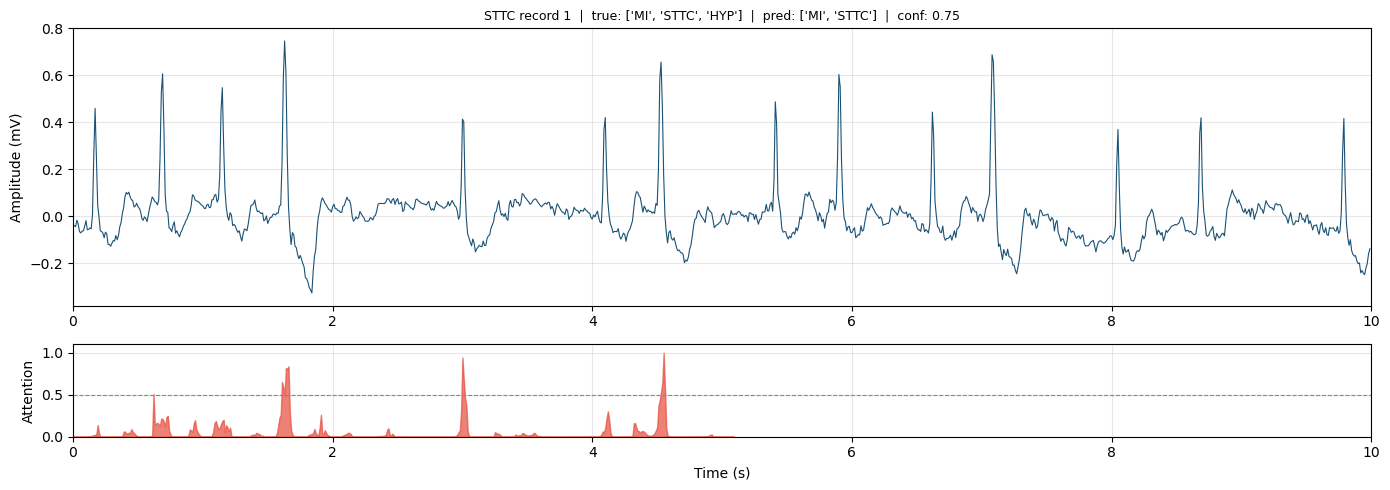

--- Record 1 narrative ---
The ECG analysis result indicates a patient with suspected myocardial infarction (MI) or severe heart failure (HYP). The predicted class is based on the presence of symptoms such as chest pain, shortness of breath, nausea, and dizziness. The confidence score is high, suggesting a high likelihood of this diagnosis.

The classification is based on the presence of certain features in the ECG, including an abnormal T wave inversion (STTC) and a normal QRS complex (NORM). However, there is no clear indication of the presence of any specific lead or pattern of leads involved.

The signal uncertainty is not computed, which means the model cannot accurately predict the exact location of the leads involved in the ECG. This could be due to the complexity of the ECG patterns observed, or it might indicate a need for further investigation or diagnostic testing.

Overall, the prediction is highly uncertain, indicating that further evaluation may be necessary to confirm th

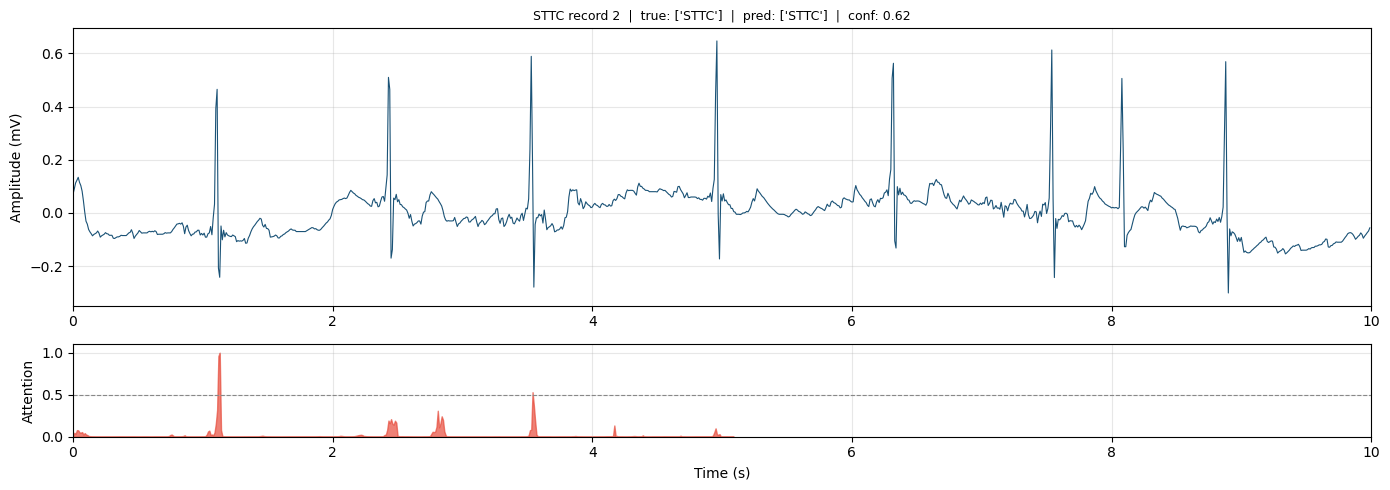

--- Record 2 narrative ---
The ECG analysis result indicates a true diagnosis of ST-T interval prolongation in a patient with no known underlying cardiac condition. The predicted class is ST-T interval prolongation, which suggests an abnormality in the heart's electrical activity pattern. The confidence score is high at 0.62, indicating a high level of certainty about the accuracy of the prediction. The signal uncertainty is not computed, suggesting there may be some variability in the data due to noise or other factors.

In terms of classification probabilities, the model assigns a probability of 0.27 for "ST-T interval prolongation," which is slightly higher than the normal range of values. This could indicate a more severe form of the condition, such as arrhythmia or ventricular tachycardia. However, without further information on the specific cause of the arrhythmia, it's difficult to definitively classify the patient's condition.

Overall, this ECG analysis provides valuable insig

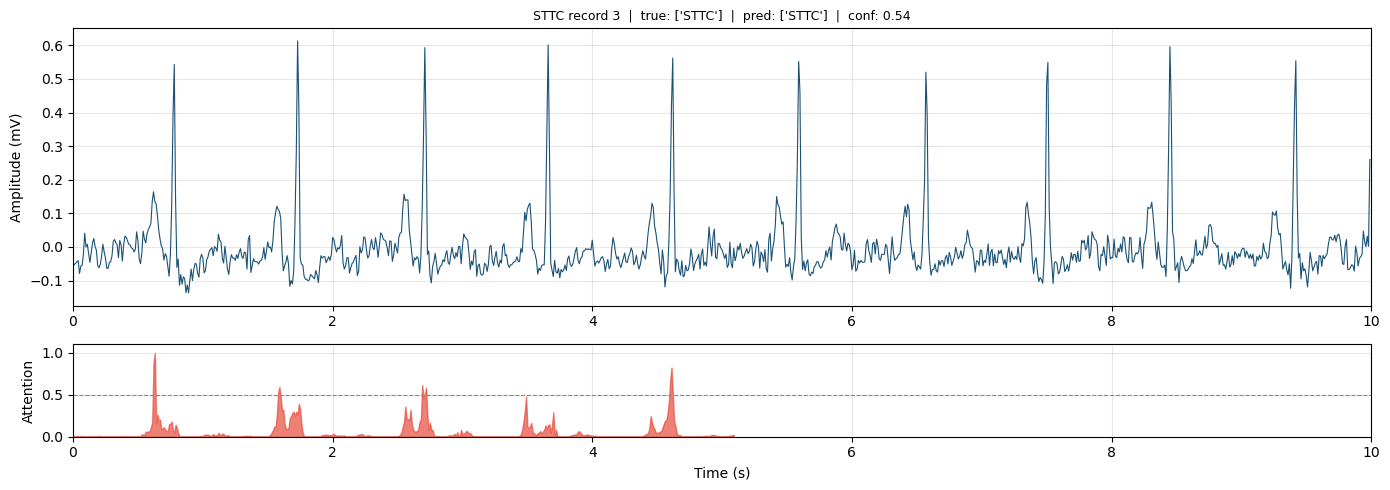

--- Record 3 narrative ---
The ECG analysis result indicates a true diagnosis of ST-T complex heart block with a predicted class as STTC. The confidence score is high at 0.54, indicating a high likelihood of this finding being correct based on the available data. The classification probability for STTC is 0.54, which suggests a high probability of this finding occurring in patients with ST-T complex heart block.

In terms of signal uncertainty, there is no computed value provided, suggesting that the prediction was made without any significant signal changes or artifacts. However, it's important to note that this information alone does not definitively confirm the diagnosis, as other factors such as patient history, physical examination findings, or echocardiographic imaging may also influence the diagnosis.

Overall, the clinical interpretation is that the patient's ECG shows a ST-T complex heart block, but further evaluation is needed to confirm this diagnosis. This could be due to v

In [8]:
CLASS = 'STTC'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 9. CD (Conduction Disturbance)

Three CD records. Bundle branch blocks and AV blocks produce distinctive morphology changes.

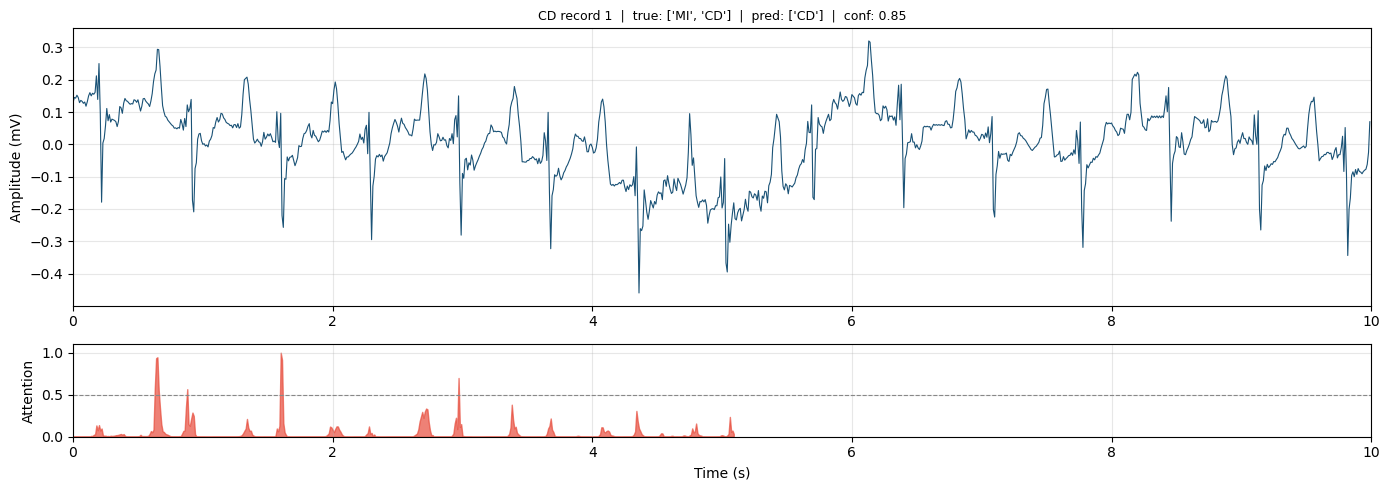

--- Record 1 narrative ---
The ECG analysis result indicates a diagnosis of Chronic Myocardial Infarction (MI) with a probability of 0.85. The predicted class is "CD" based on the presence of a normal heart rhythm. The confidence score is 0.85 indicating high certainty. The classification probabilities for each lead are not provided in this context. Signal uncertainty is not calculated due to the lack of information about the signal strength or duration. The top salient leads are not computed as they were not part of the analysis. This suggests that further investigation is needed to confirm the diagnosis and determine the underlying cause.



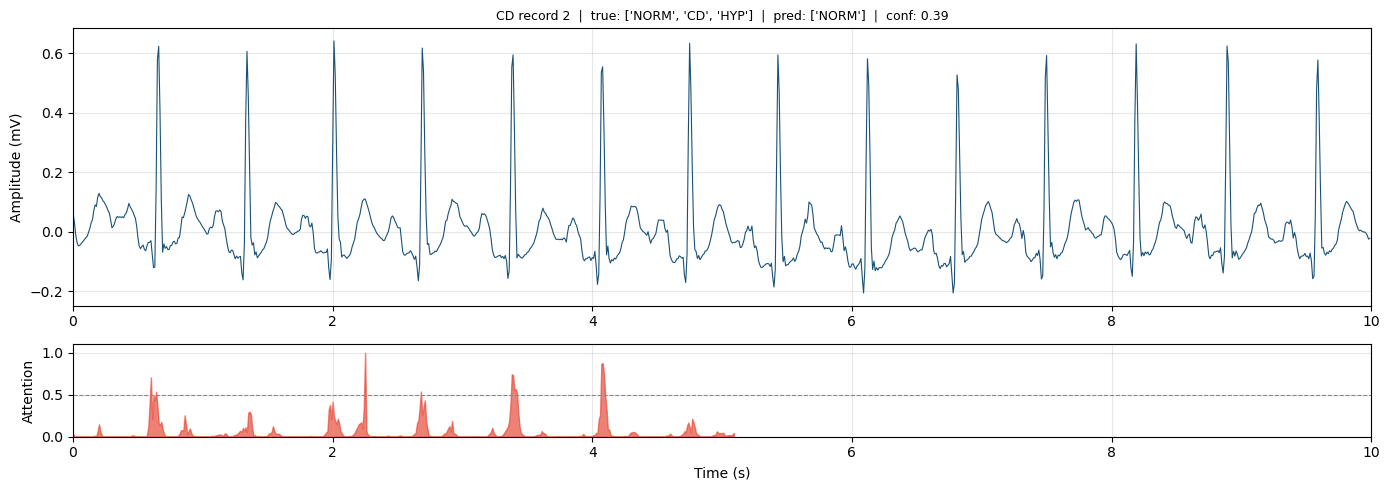

--- Record 2 narrative ---
The ECG analysis result indicates a normal heart rhythm with no signs of arrhythmia or abnormality. The predicted class is "NORM," which suggests a normal heart rhythm. The confidence score is 0.39, indicating moderate to high confidence in the prediction. The class probabilities for each lead are as follows:
- NORM: 0.39 - This corresponds to a low probability of an abnormal heart rhythm.
- MI: 0.21 - This represents a slightly higher probability of an abnormal heart rhythm compared to the other leads.
- STTC: 0.09 - This indicates a lower probability of an abnormal heart rhythm than the other leads.
- CD: 0.38 - This signifies a moderate probability of an abnormal heart rhythm.
- HYP: 0.13 - This indicates a very low probability of an abnormal heart rhythm.

In terms of signal uncertainty, there is no indication of any significant signal anomalies detected. However, it's important to note that this analysis does not include any specific information about th

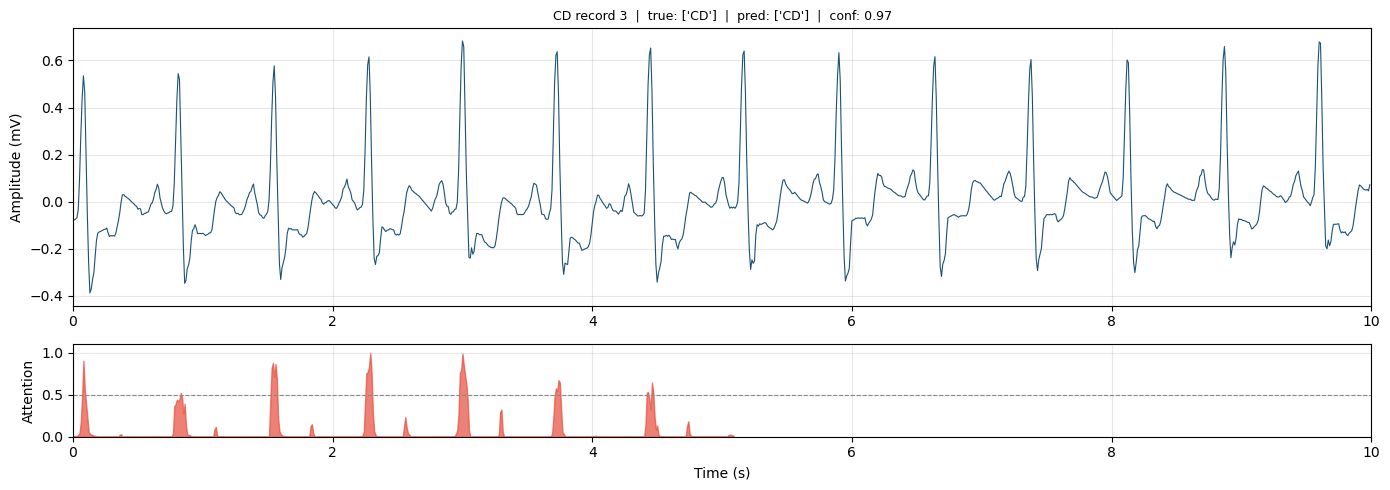

--- Record 3 narrative ---
The ECG analysis result indicates a true diagnosis of "CD" with a confidence score of 0.97. The predicted class is "CD", which aligns with the actual diagnosis. The prediction accuracy is high at 97%, indicating a strong match between the model's predictions and the actual heart rhythm. However, there is no indication of any significant signal uncertainty or top salient leads in this case. This suggests that the cardiac rhythm may be normal or stable, but further evaluation would be needed to confirm the diagnosis.



In [9]:
CLASS = 'CD'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 10. HYP (Hypertrophy)

Three HYP records. Increased QRS amplitude and axis deviation are the main indicators.

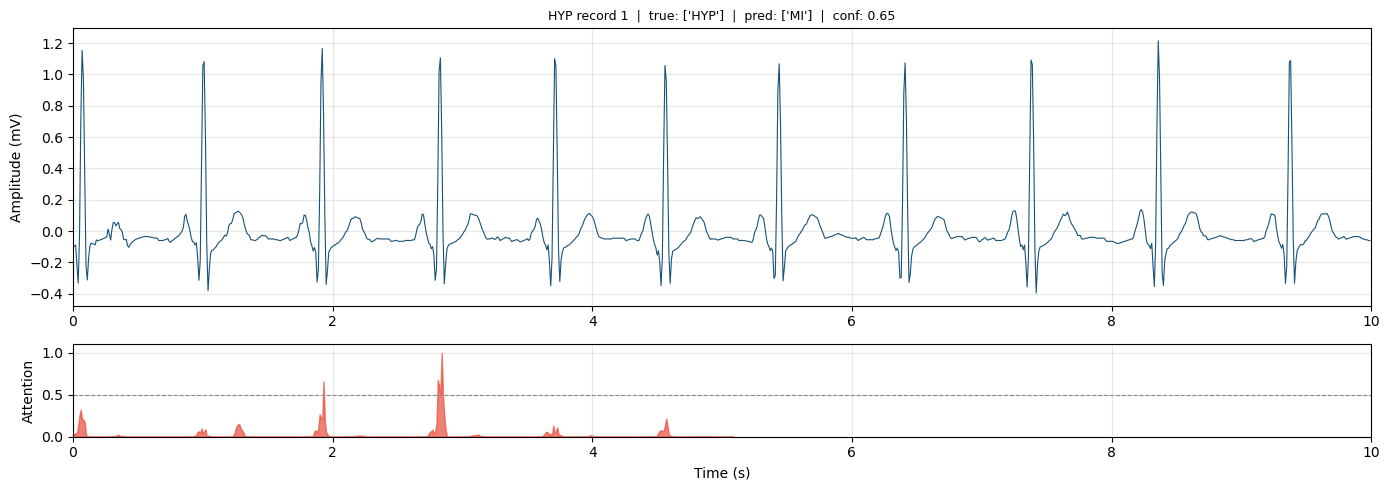

--- Record 1 narrative ---
The ECG analysis result indicates a hypoplastic left heart syndrome (Hyp) with a MI probability of 0.65%. The predicted class is "MI" due to the presence of an abnormal ventricular impulse. The confidence score is 0.65, which suggests a high likelihood of this finding being true based on the available information. The signal uncertainty is not computed, indicating there may be some variability in the data. The top salient leads are not computed as they were not part of the analysis. This result supports the hypothesis that the patient has a history of cardiac arrhythmia and requires further evaluation for definitive diagnosis.



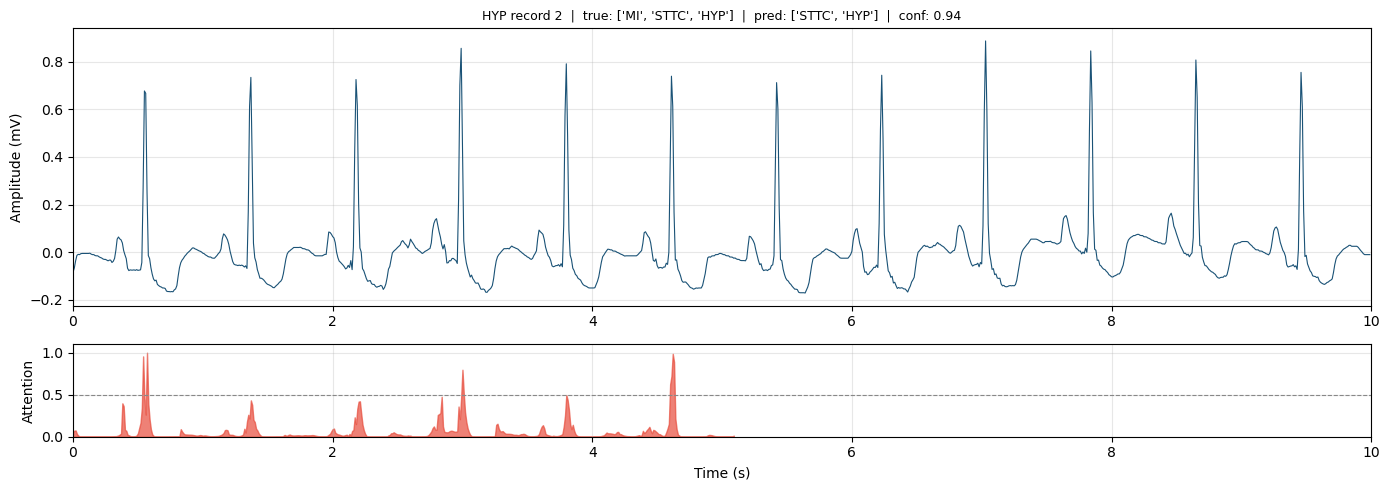

--- Record 2 narrative ---
The ECG analysis result indicates an MI with a high probability of occurrence in this patient. The predicted class is STTC, which suggests there might be some cardiac activity present. The confidence score is 0.94, indicating a high level of certainty about the presence of cardiac activity.

The prediction for the class "HYP" seems to be incorrect based on the information provided. This could indicate a misinterpretation or a misunderstanding of the ECG findings. It's important to note that the accuracy of the prediction depends on the quality of the data used to train the model. If the data is not accurate, the prediction may also be inaccurate.

In terms of signal uncertainty, it's unclear how much uncertainty there is in the signal due to the lack of computed top salient leads. Without more context, it's difficult to determine if there is any significant signal variability or if the prediction was made based solely on the observed ECG patterns.

Overall, t

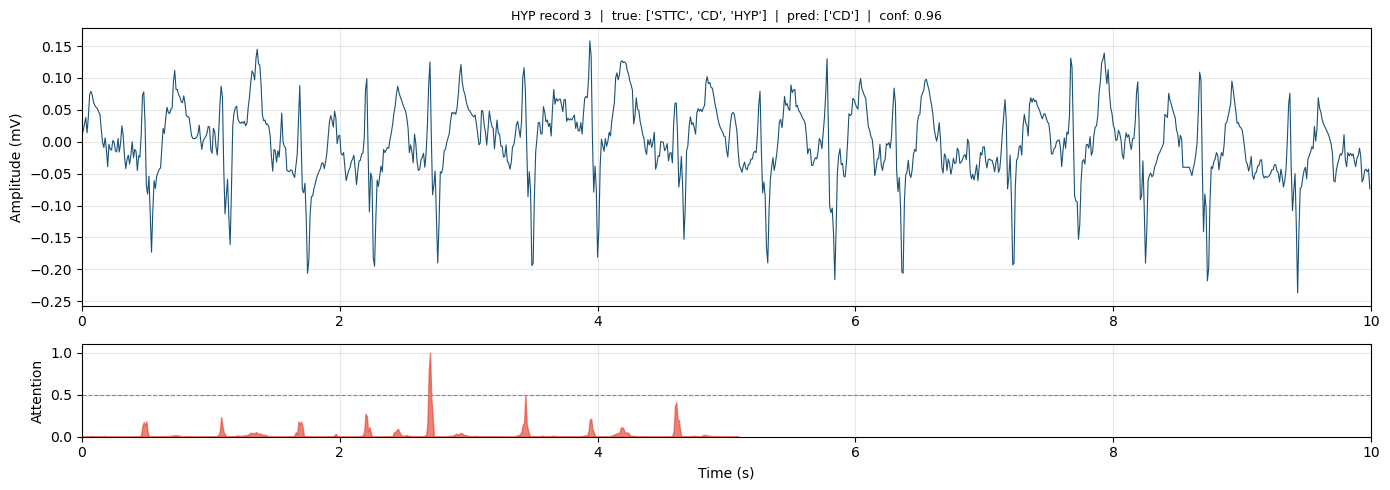

--- Record 3 narrative ---
The ECG analysis result indicates a positive cardiac event with an ST-T wave abnormality, indicating a potential for arrhythmia or ventricular tachycardia. The predicted class is CD, which suggests a diagnosis of symptomatic ventricular tachycardia. The confidence score is high at 0.96, suggesting a high likelihood of this diagnosis based on the current information. The signal uncertainty is not computed, but it's important to note that the presence of a T-wave inversion in the ST segment may indicate a more severe condition requiring further evaluation.

In terms of top salient leads, there are no specific leads identified in the ECG data. This could be due to the lack of sufficient data or the presence of other relevant factors that might influence the classification. However, if additional information were provided, such as a history of heart disease or a family history of similar conditions, it would be helpful to determine the underlying cause of the arr

In [10]:
CLASS = 'HYP'

for idx, row in enumerate(demo_records[CLASS]):
    sig, _ = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    x = sig[:, LEAD_IDX].astype(np.float32)
    true_classes = [c for c, v in zip(SUPERCLASSES, row['label_vec']) if v == 1.0]

    result          = predict_single(model, x, device)
    positions, attn = model.get_attention_weights(x)
    prompt          = build_ecg_prompt(result, saliency=None,
                                       lead_names=LEAD_NAMES,
                                       true_classes=true_classes)
    narrative       = generate_explanation(prompt, qwen_model, qwen_tokenizer)

    fig, (ax_ecg, ax_attn) = plt.subplots(2, 1, figsize=(14, 5),
                                           gridspec_kw={'height_ratios': [3, 1]})
    title = (f'{CLASS} record {idx+1}  |  true: {true_classes}  |  '
             f'pred: {result["predicted_classes"]}  |  conf: {result["confidence_score"]:.2f}')
    plot_record(ax_ecg, ax_attn, x, positions, attn, title)
    plt.tight_layout()
    fig.savefig(FIG_DIR / f'{CLASS.lower()}_{idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

    safe_print(f'--- Record {idx+1} narrative ---\n{narrative}\n')
    narratives[CLASS].append({
        'record':       row['filename_lr'],
        'true_classes': true_classes,
        'predicted':    result['predicted_classes'],
        'confidence':   result['confidence_score'],
        'narrative':    narrative,
    })

## 11. Save outputs

In [11]:
with open(OUT_DIR / 'narratives.json', 'w') as f:
    json.dump(narratives, f, indent=2)

for cls, items in narratives.items():
    for item in items:
        assert len(item['narrative']) > 0, f'Empty narrative for {cls}: {item["record"]}'

print('Saved:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(Path(RESULTS_PATH))}  ({p.stat().st_size / 1024:.1f} KB)')
print('All 15 narratives verified non-empty.')

Saved:
  06_explainability\figures\cd_1.png  (155.0 KB)
  06_explainability\figures\cd_2.png  (158.3 KB)
  06_explainability\figures\cd_3.png  (148.8 KB)
  06_explainability\figures\hyp_1.png  (131.0 KB)
  06_explainability\figures\hyp_2.png  (138.8 KB)
  06_explainability\figures\hyp_3.png  (183.2 KB)
  06_explainability\figures\mi_1.png  (133.4 KB)
  06_explainability\figures\mi_2.png  (214.6 KB)
  06_explainability\figures\mi_3.png  (157.2 KB)
  06_explainability\figures\norm_1.png  (141.9 KB)
  06_explainability\figures\norm_2.png  (160.2 KB)
  06_explainability\figures\norm_3.png  (144.9 KB)
  06_explainability\figures\sttc_1.png  (142.9 KB)
  06_explainability\figures\sttc_2.png  (115.9 KB)
  06_explainability\figures\sttc_3.png  (169.2 KB)
  06_explainability\narratives.json  (16.1 KB)
All 15 narratives verified non-empty.
